# EDA Dataset City Branding Skema 2

Notebook ini digunakan untuk eksplorasi awal dataset `labels_skema2.xlsx`, terutama visualisasi sebaran label pada kolom `Anotasi`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
candidate_paths = [
    Path("../dataset/labels_skema2.xlsx"),  # jika notebook dijalankan dari folder multimodal_citybranding
    Path("dataset/labels_skema2.xlsx"),     # jika notebook dijalankan dari root project
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("File dataset/labels_skema2.xlsx tidak ditemukan dari working directory saat ini.")

df = pd.read_excel(data_path)
df.head()

,Post URL,File,Post Date,Caption,Anotasi,Catatan
0,https://www.instagram.com/p/DXyhP25j7o3/,1.jpg,2026-05-01 08:29:19,"The beach is fun, while the mountains are calm...",Attraction,NaN
1,https://www.instagram.com/p/C-Id93hyegu/,2.jpg,2024-08-01 15:27:41,"Pantai Slimpuyang , Sidomulyo , Lampung selata...",Attraction,NaN
2,https://www.instagram.com/p/DRY11KTj8nt/,3.jpg,2025-11-23 06:00:00,"A welcoming spot where groups can find shade, ...",Amenities,NaN
3,https://www.instagram.com/p/DBFjvtxyijQ/,4.jpg,2024-10-14 01:54:38,The beach is the answer to relieve fatigue fro...,Attraction,NaN
4,https://www.instagram.com/p/DMzwtWsx-N1/,5.jpg,2025-08-01 10:18:19,Thank you for visiting at minangrua beach🌊☀\n—...,Ancillary,NaN


In [3]:
print(f"Jumlah baris: {len(df):,}".replace(",", "."))
print(f"Jumlah kolom: {df.shape[1]}")
print("Kolom:", list(df.columns))

Jumlah baris: 695
Jumlah kolom: 6
Kolom: ['Post URL', 'File', 'Post Date', 'Caption', 'Anotasi', 'Catatan']


In [4]:
if "Anotasi" not in df.columns:
    raise KeyError("Kolom 'Anotasi' tidak ditemukan di dataset.")

anotasi_bersih = df["Anotasi"].astype("string").str.strip()
anotasi_bersih = anotasi_bersih.mask(anotasi_bersih.isna() | anotasi_bersih.eq(""), "Tidak berlabel")

label_counts = (
    anotasi_bersih.value_counts()
    .rename_axis("Anotasi")
    .reset_index(name="Jumlah")
)
label_counts["Persentase"] = (label_counts["Jumlah"] / label_counts["Jumlah"].sum() * 100).round(2)

label_counts

,Anotasi,Jumlah,Persentase
0,Attraction,593,85.32
1,Amenities,63,9.06
2,Ancillary,30,4.32
3,Accessibility,9,1.29


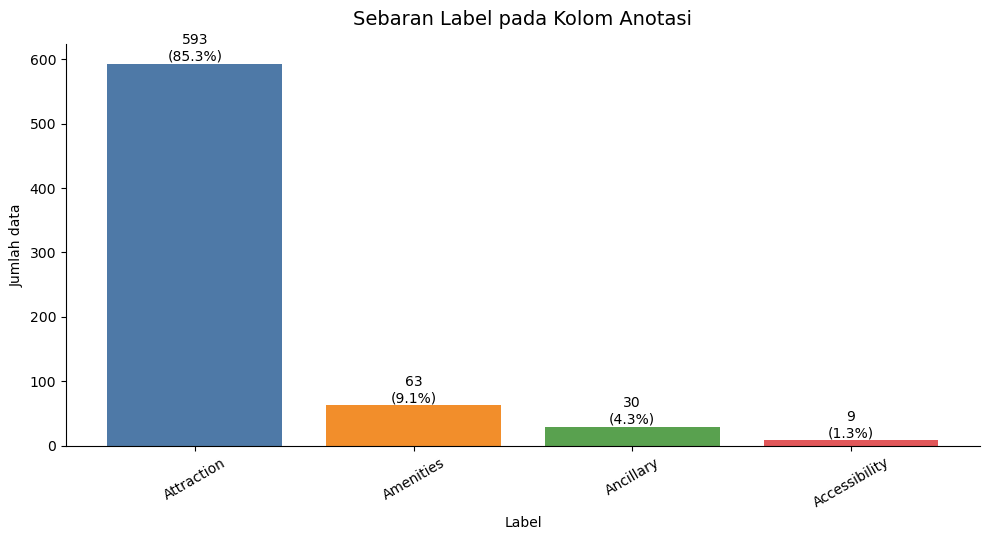

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#76B7B2", "#EDC949"]

bars = ax.bar(label_counts["Anotasi"], label_counts["Jumlah"], color=colors[: len(label_counts)])

ax.set_title("Sebaran Label pada Kolom Anotasi", fontsize=14, pad=14)
ax.set_xlabel("Label")
ax.set_ylabel("Jumlah data")
ax.tick_params(axis="x", rotation=30)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, jumlah, persen in zip(bars, label_counts["Jumlah"], label_counts["Persentase"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{jumlah}\n({persen:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()